# Uncalibrated risk calculations

This notebook will walk through the a risk calculation in CLIMADA with the uncalibrated data. It will look at impacts from the event footprint for the 2024 Porto Alegre flood.

It will read in data, create the CLIMADA objects needed for the analysis, run the risk calculation, and explore the outputs including plots and statistics.

This analysis is being performed with the _uncalibrated_ Entity files containing our first guess impact functions. Therefore the purpose of this notebook is also to notice the shortcomings of the analysis and identify how it has to be improved.

In [12]:
from pathlib import Path

# Set up paths to data
ENTITY_DIR = "../data/entity_files_uncalibrated/"
ENTITY_FILES = ["Porto_Alegre_BRAZIL_Entity_Floods_Residential.xlsx", "Porto_Alegre_BRAZIL_Entity_Floods_Companies.xlsx", "Porto_Alegre_BRAZIL_Entity_Floods_Schools.xlsx"]
entity_filepaths = [Path(ENTITY_DIR) / filename for filename in ENTITY_FILES]

HAZARD_DIR = "../data/hazard/"
HAZARD_FILE = "Brazil_Porto_Alegre_HAZARD.tif"
haz_filepath = Path(HAZARD_DIR) / HAZARD_FILE

## Read in data

### Entity files

In [ ]:
import copy
from climada.entity import Entity

# Plot affected Exposures
impf_column = "impf_FL"   # Impact function column in the Entity file's assets table

# Set values of individual assets (used later)
RESIDENCE_VALUE_USD = 375_275
COMPANY_VALUE_USD = 90_932
SCHOOL_VALUE_USD = 500_000

# Read the Entity file and set additional metadata for the Exposures
entity_list = []
for entity_path in entity_filepaths:
    print(f"Reading {entity_path.name}...")
    entity = Entity.from_excel(entity_path)
    entity.exposures.ref_year = 2024
    entity.exposures.value_unit = "USD"   # This needs to be specified but will be read from the Excel file after the next release
    entity.exposures.description = f"Exposures from {entity_path.name}"
    entity_list.append(entity)

entity_residences, entity_companies, entity_schools = entity_list
entity_names = ["residences (economic impact)", "companies (economic impact)", "schools (economic impact)"]

Reading Porto_Alegre_BRAZIL_Entity_Floods_Residential.xlsx...
Reading Porto_Alegre_BRAZIL_Entity_Floods_Companies.xlsx...
Reading Porto_Alegre_BRAZIL_Entity_Floods_Schools.xlsx...


### Plot exposures

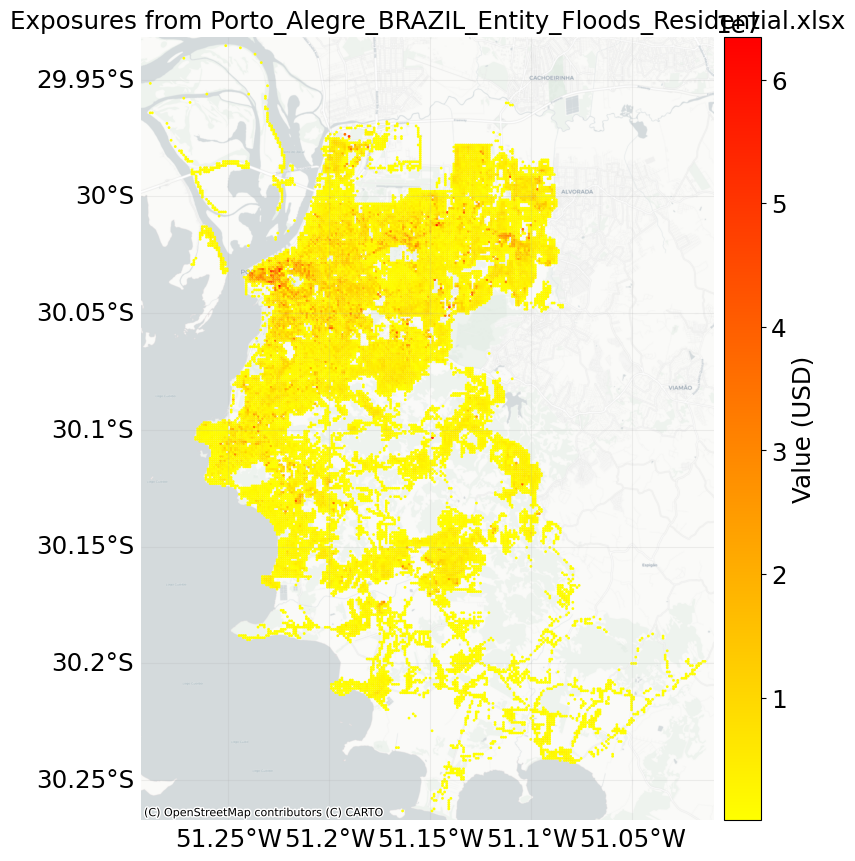

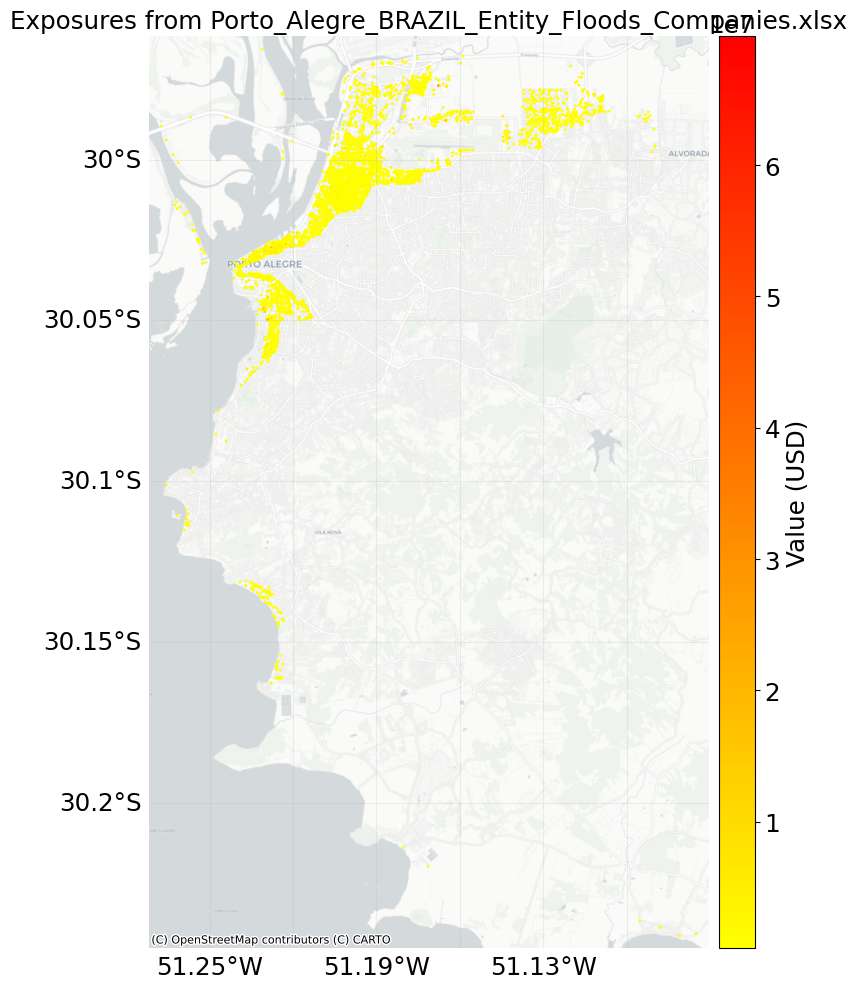

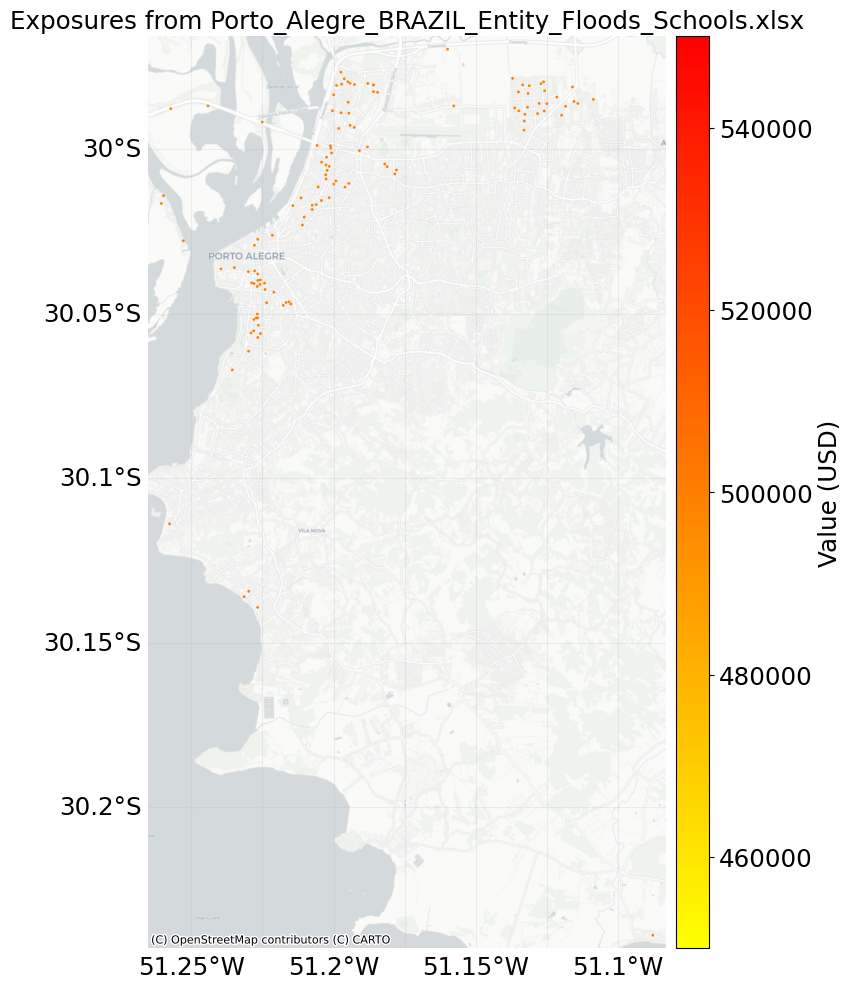

In [9]:
%matplotlib inline

for entity in entity_list:
    entity.exposures.plot_basemap(
        title=entity.exposures.description,
        ignore_zero=True,       # Whether to plot points with zero value
        buffer=500,              # Add a buffer around the points to show a larger map region (measured in meters)
        s=1,                     # The size of point markers on the plot
        zoom=13,                 # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=None,               # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)         # Dimensions of the output figure
    )

### Plot impact functions

- The Residential Entity file contains three first-guess impact functions: a generalized damage curve for economic impacts, and two step functions that count affected and destroyed housing.
- The People Entity file contains two first-guess impact functions: step functions that count people affected and 'victims' – roughly corresponding to people who were displaced from their homes.
- The Roads Entity file contains a single first-guess impact function.

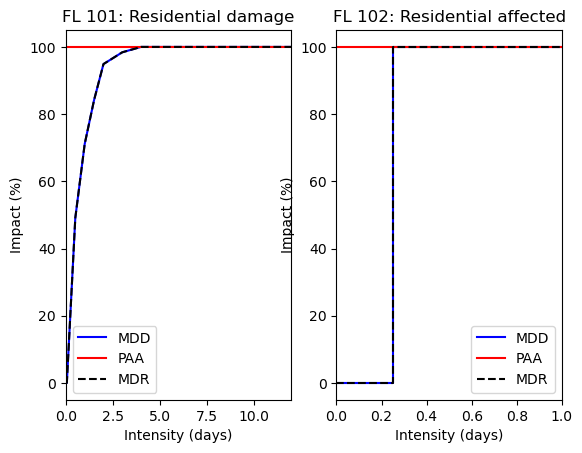

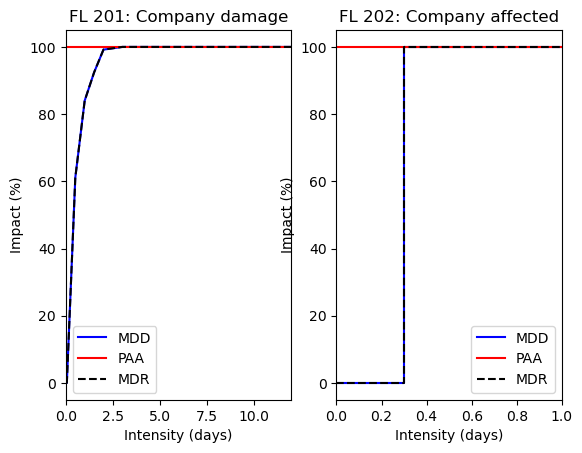

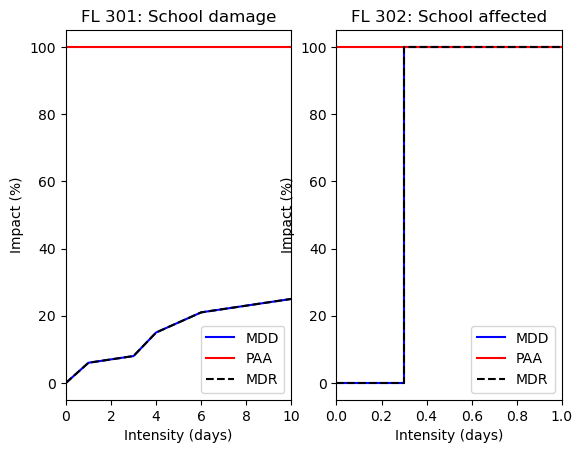

In [10]:
for entity in entity_list:
    entity.impact_funcs.plot()

### Hazard

In [18]:
import copy
import numpy as np
from climada.hazard import Hazard

# Read in the hazard data
haz = Hazard.from_raster(
    files_intensity = haz_filepath,
    attrs={
        'unit': 'days',
        'event_name': ['2024 Flood'],     # We can optionally name the events
        'frequency': np.array([1])                  # For a historic event reconstruction we set the frequency to 1: there is no probabilistic analysis to do here
    },
    haz_type='FL',
    window=None,          # Only read a window from the raster datasets, provided as a rasterio.windows.Windows object 
    geometry=None,        # Only read within a given geometry, provided as a list of shapely.geometry objects
)

2026-06-09 08:06:47,548 - climada.util.coordinates - INFO - Reading ../data/hazard/Brazil_Porto_Alegre_HAZARD.tif
2026-06-09 08:06:49,595 - climada.util.coordinates - INFO - Reading ../data/hazard/Brazil_Porto_Alegre_HAZARD.tif


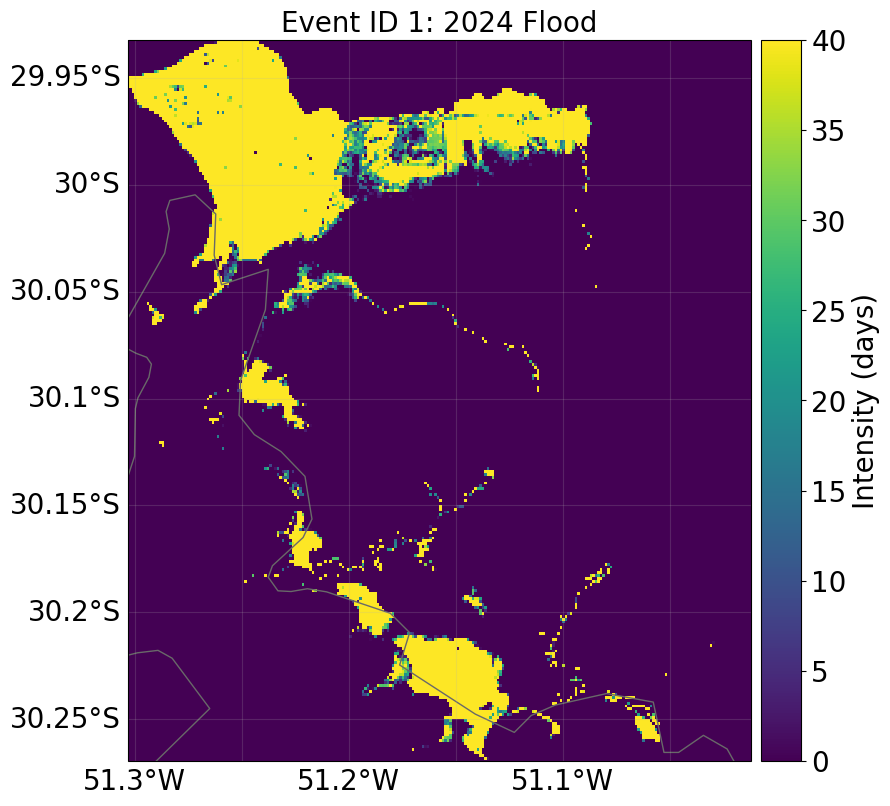

In [34]:
# Plot the event
_ = haz.plot_intensity(event=1, vmax=40)

### Map Hazard centroids to Exposure points

When CLIMADA is given a hazard and an exposure dataset it has to infer the intensity of the hazard at every exposure point. Often the hazard centroids and the exposure locations do not line up exactly. In these cases, CLIMADA finds the closest hazard centroid for each exposure, within a certain maximum search distance, set by a `threshold` parameter (or estimated by the model if not provided).

The hazard in this dataset is on a regular grid, and so CLIMADA is able to choose a distance threshold and map to the nearest centroids without difficulty.

In [15]:
for entity in entity_list:
    entity.exposures.assign_centroids(hazard=haz, overwrite=True)

2026-06-09 07:56:22,717 - climada.entity.exposures.base - INFO - Matching 20187 exposures with 1354664 centroids.
2026-06-09 07:56:24,154 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0005387914992240894 degree
2026-06-09 07:56:24,597 - climada.entity.exposures.base - INFO - Matching 4366 exposures with 1354664 centroids.
2026-06-09 07:56:25,705 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0005387914992240894 degree
2026-06-09 07:56:26,200 - climada.entity.exposures.base - INFO - Matching 122 exposures with 1354664 centroids.
2026-06-09 07:56:26,973 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0005387914992240894 degree


## Calculate risk

With all these ingredients we can run risk calculations using CLIMADA's `ImpactCalc` class.

Each Entity file contains two impact functions: a curve for economic loss, and a step function to find affected locations. We will run both analyses.

We start by writing a method that changes the impact function assigned to the Exposures in the Entity file so that we can easily switch between impact functions:

In [ ]:
# Method to change the impact function assigned to the Exposures
def change_entity_exposure_impf(entity, new_impf_id):
    new_gdf = copy.deepcopy(entity.exposures.gdf)
    new_gdf["impf_id"] = new_impf_id
    entity.exposures.set_gdf(new_gdf)
    return entity

In [19]:
from climada.engine import ImpactCalc, ImpactFreqCurve

# ----------------------------------------
# Impact: economic impacts on residences
# ----------------------------------------

# The ImpactCalc class sets up the calculation
imp_calc_residences_economic = ImpactCalc(
    exposures=entity_residences.exposures,
    impfset=entity_residences.impact_funcs,
    hazard=haz
)
# ...and its .impact method runs the calculation, creating an Impact object
imp_residences_economic = imp_calc_residences_economic.impact(
    save_mat=True,          # Save the impact matrix (see below). This can be large, but we want it to explore some additional calculations 
    assign_centroids=False  # Don't (re)assign centroids
)


# ----------------------------------------
# Impact: affected residences
# ----------------------------------------

# Change the impact function assigned to the Exposures
entity_residences_affected = change_entity_exposure_impf(entity_residences, new_impf_id=102)

# Run the impact calculation again
imp_calc_residences_affected = ImpactCalc(
    exposures=entity_residences_affected.exposures,
    impfset=entity_residences_affected.impact_funcs,
    hazard=haz
)
imp_residences_affected = imp_calc_residences_affected.impact(
    save_mat=True,
    assign_centroids=False
)

2026-06-09 08:07:12,740 - climada.engine.impact_calc - INFO - Calculating impact for 100935 assets (>0) and 1 events.
2026-06-09 08:07:12,809 - climada.engine.impact_calc - INFO - Calculating impact for 100935 assets (>0) and 1 events.


In [20]:
# And we can repeat this impact calculation for companies and schools exposures:

# ----------------------------------------
# Impact: economic impacts on companies
# ----------------------------------------

imp_calc_companies_economic = ImpactCalc(
    exposures=entity_companies.exposures,
    impfset=entity_companies.impact_funcs,
    hazard=haz
)
imp_companies_economic = imp_calc_companies_economic.impact(
    save_mat=True,
    assign_centroids=False
)

# ----------------------------------------
# Impact: affected companies
# ----------------------------------------

entity_companies_affected = change_entity_exposure_impf(entity_companies, new_impf_id=202)
imp_calc_companies_affected = ImpactCalc(
    exposures=entity_companies_affected.exposures,
    impfset=entity_companies_affected.impact_funcs,
    hazard=haz
)
imp_companies_affected = imp_calc_companies_affected.impact(
    save_mat=True,
    assign_centroids=False
)

# ----------------------------------------
# Impact: economic impacts on schools
# ----------------------------------------

imp_calc_schools_economic = ImpactCalc(
    exposures=entity_schools.exposures,
    impfset=entity_schools.impact_funcs,
    hazard=haz
)
imp_schools_economic = imp_calc_schools_economic.impact(
    save_mat=True, 
    assign_centroids=False
)

# ----------------------------------------
# Impact: affected schools
# ----------------------------------------

entity_schools_affected = change_entity_exposure_impf(entity_schools, new_impf_id=302)
imp_calc_schools_affected = ImpactCalc(
    exposures=entity_schools_affected.exposures,
    impfset=entity_schools_affected.impact_funcs,
    hazard=haz
)
imp_schools_affected = imp_calc_schools_affected.impact(
    save_mat=True,
    assign_centroids=False
)

2026-06-09 08:07:16,524 - climada.engine.impact_calc - INFO - Calculating impact for 21830 assets (>0) and 1 events.
2026-06-09 08:07:16,550 - climada.engine.impact_calc - INFO - Calculating impact for 21830 assets (>0) and 1 events.
2026-06-09 08:07:16,588 - climada.engine.impact_calc - INFO - Calculating impact for 610 assets (>0) and 1 events.
2026-06-09 08:07:16,627 - climada.engine.impact_calc - INFO - Calculating impact for 610 assets (>0) and 1 events.


The Impact object has properties and methods that support you in creating risk statistics.

At the core of it is the impact matrix, which is a sparse matrix with dimensions (number of events) x (number of exposure points). It gives the calculated impact of each event at each point of exposure.

We explore this for the economic impacts we've calculated:

In [ ]:
import matplotlib.pyplot as plt

for imp, asset_name in zip([imp_residences_economic, imp_companies_economic, imp_schools_economic], entity_names):
    print("\n" + asset_name.upper())
    print(f"Number of exposures: {len(imp.eai_exp):,}")
    print(f"Number of events: {len(imp.event_id)}")
    print(f"Size of impact matrix: {imp.imp_mat.shape}")

    # Summing the impact across all exposed points gives us the total impact per event. This is calculated during the impact calculation and stored in the `.at_event` attribute.
    print("Total impact per event:")
    print([f'{event_name}: {impact:,.0f} {imp.unit}' for event_name, impact in zip(imp.event_name, imp.at_event)])

    # Combining the event-wise impacts with the events' frequencies let us calculate the average annual loss (AAL). This is stored in the `.aal_agg` attribute.
    # For a single event with a frequency of 1, the AAL is the same as the total impact.
    print(f"Average annual impact (AAI, or AAL) per event: {imp.aai_agg:,.0f} {imp.unit}")



RESIDENCES (ECONOMIC IMPACT)
Number of exposures: 20,187
Number of events: 1
Size of impact matrix: (1, 20187)
Total impact per event:
['2024 Flood: 7,646,578,998 USD']
Average annual impact (AAI, or AAL) per event: 7,646,578,998 USD

COMPANIES (ECONOMIC IMPACT)
Number of exposures: 4,366
Number of events: 1
Size of impact matrix: (1, 4366)
Total impact per event:
['2024 Flood: 1,489,331,376 USD']
Average annual impact (AAI, or AAL) per event: 1,489,331,376 USD

SCHOOLS (ECONOMIC IMPACT)
Number of exposures: 122
Number of events: 1
Size of impact matrix: (1, 122)
Total impact per event:
['2024 Flood: 9,150,000 USD']
Average annual impact (AAI, or AAL) per event: 9,150,000 USD


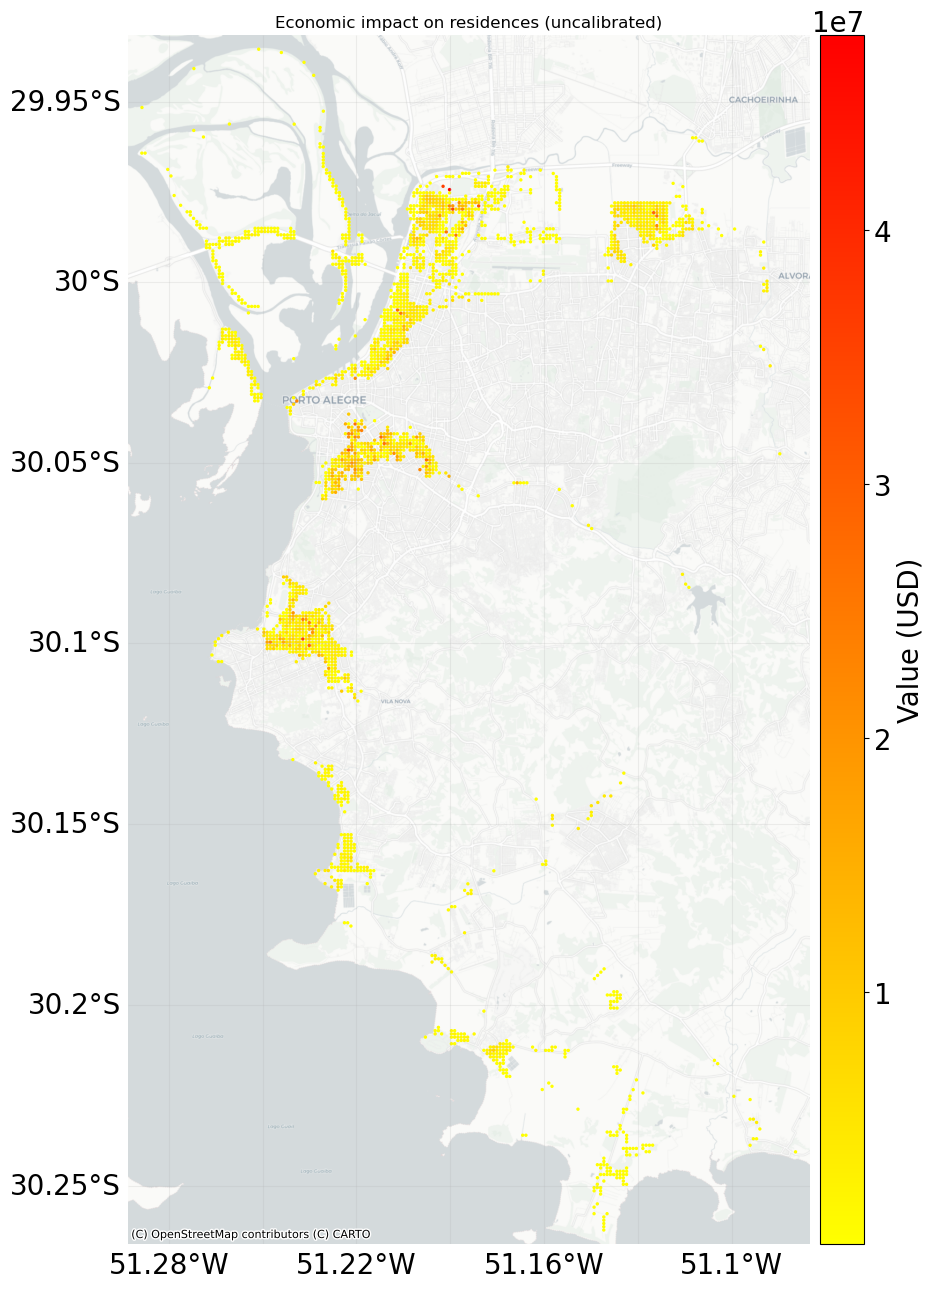

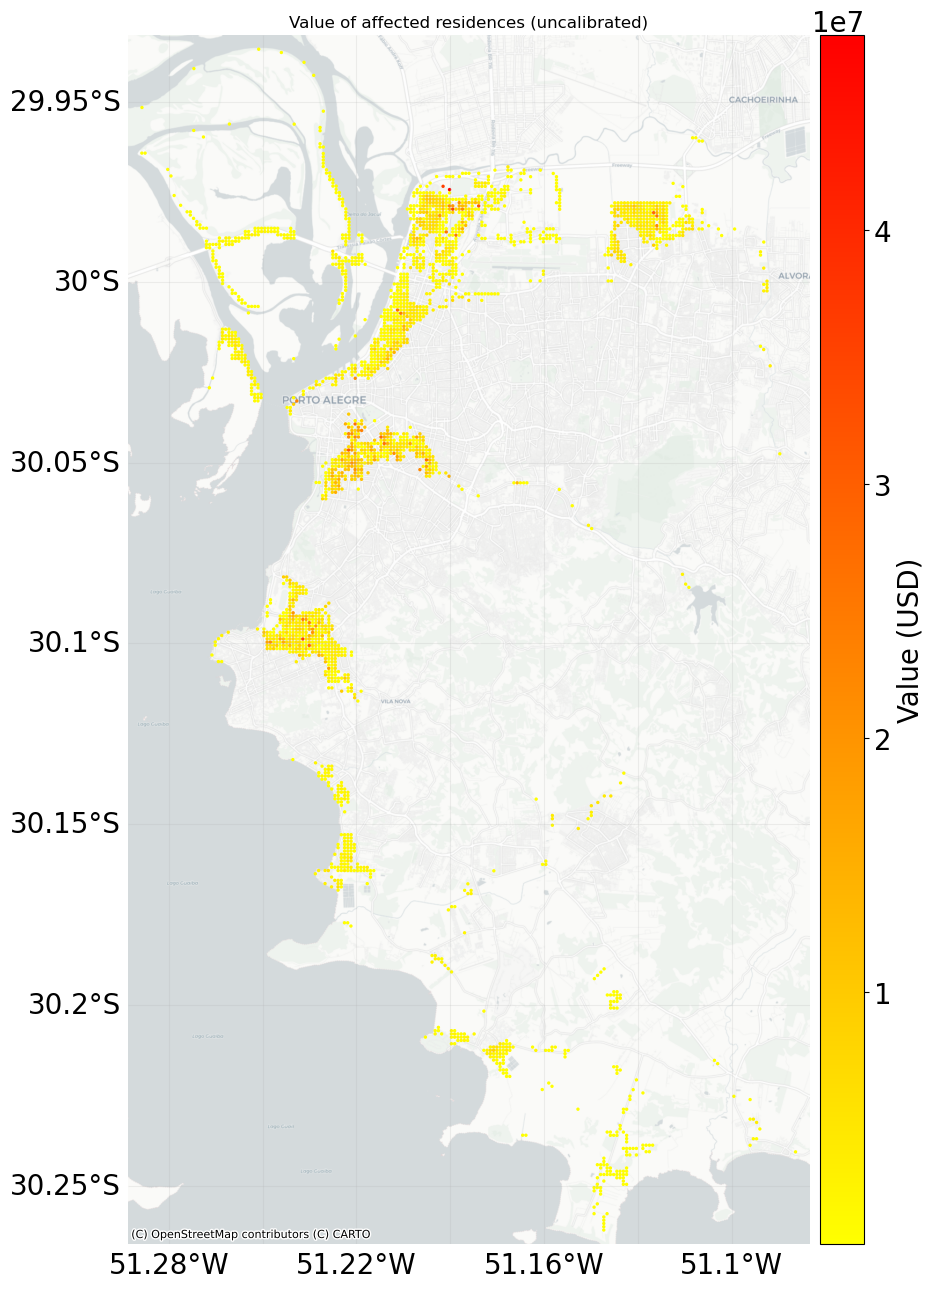

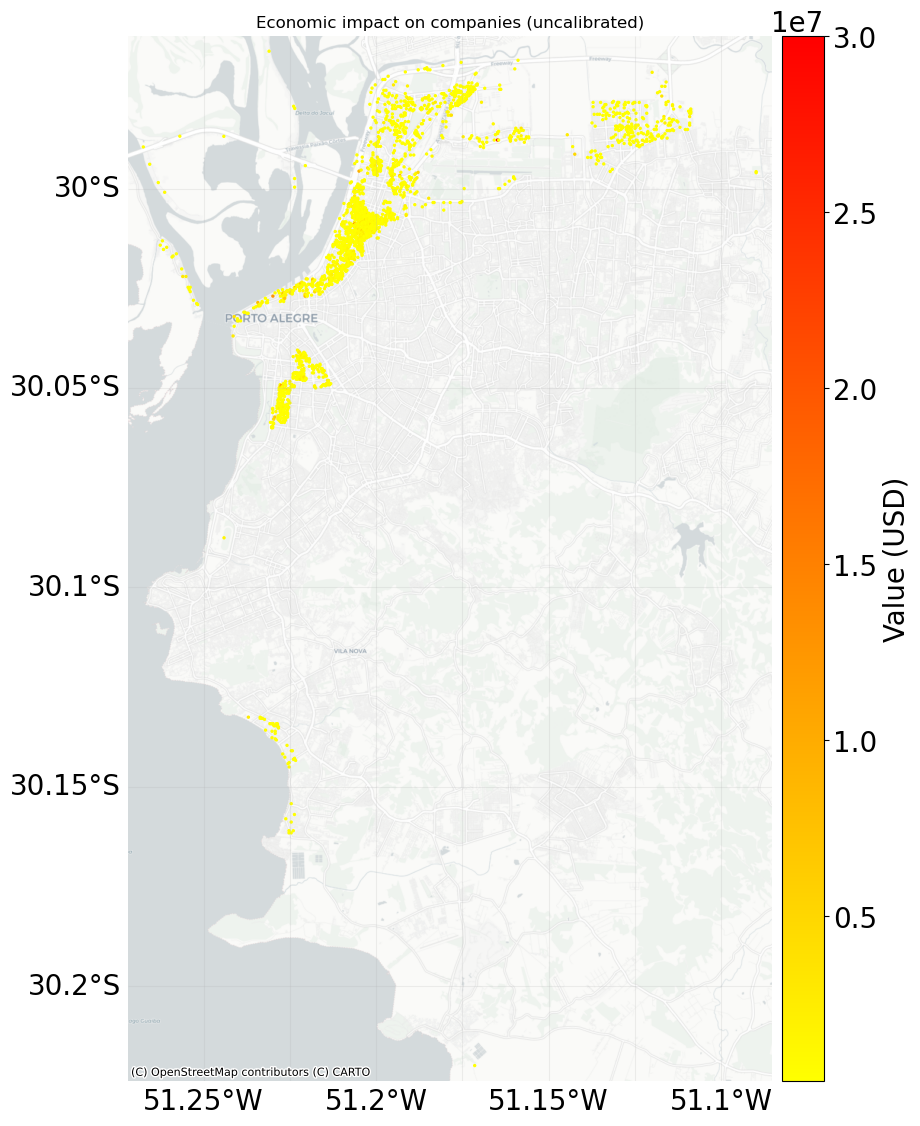

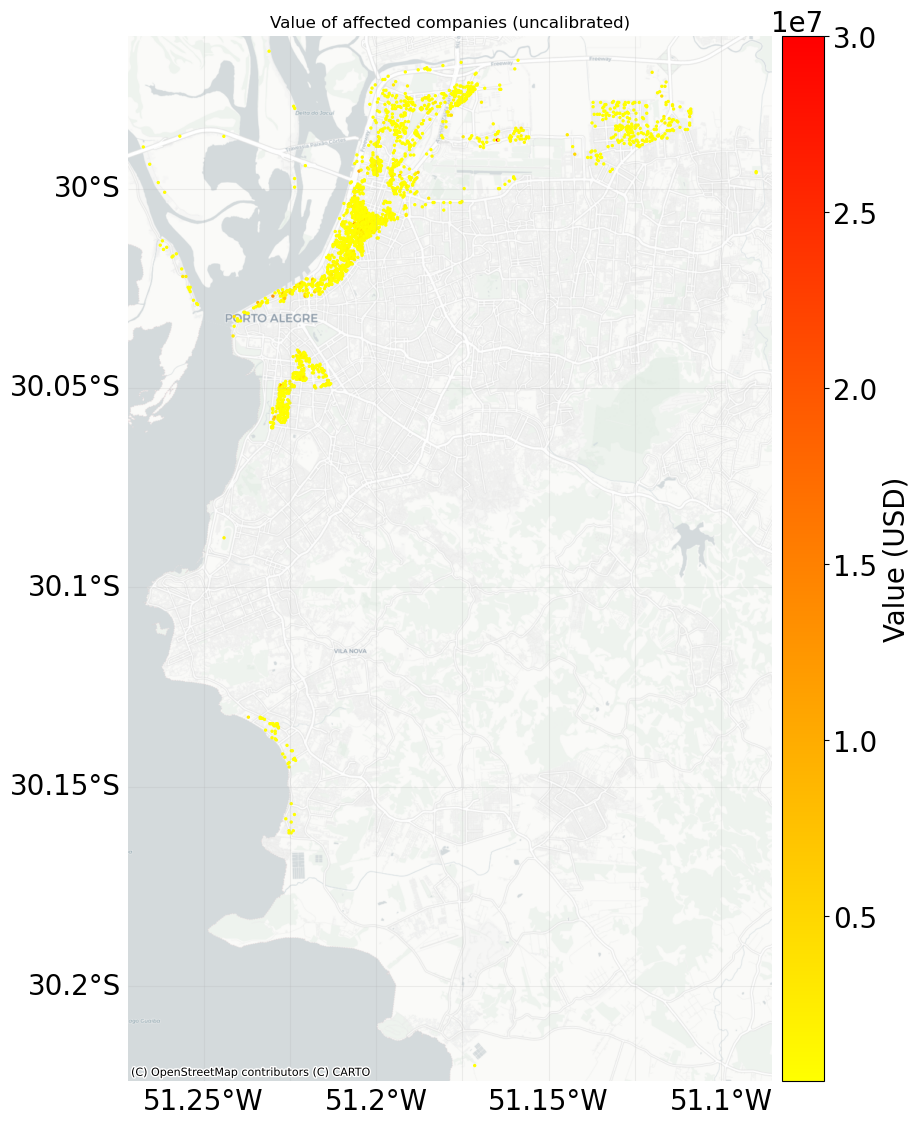

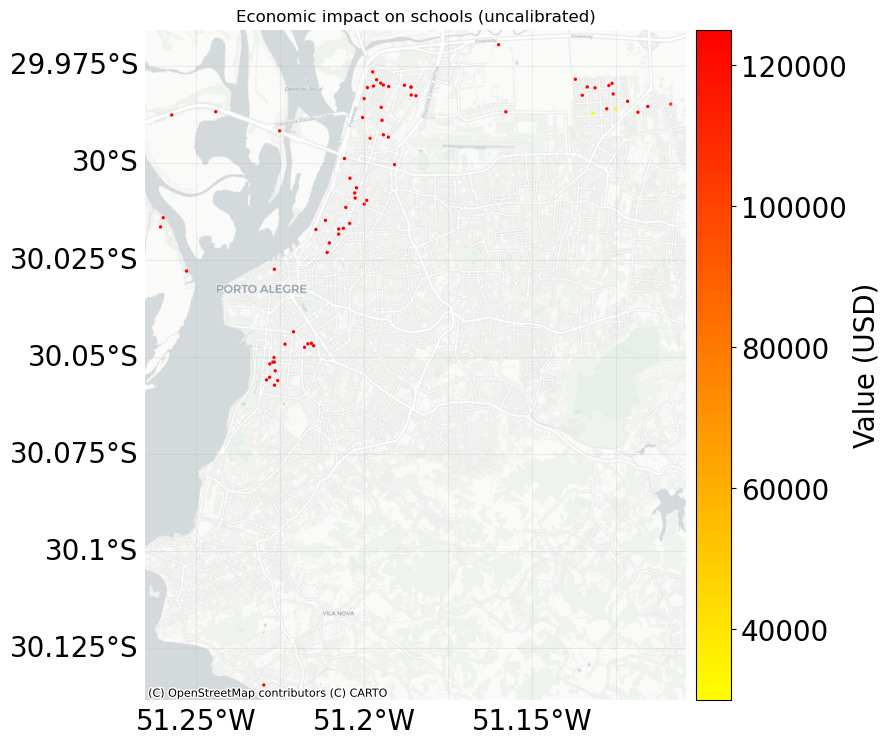

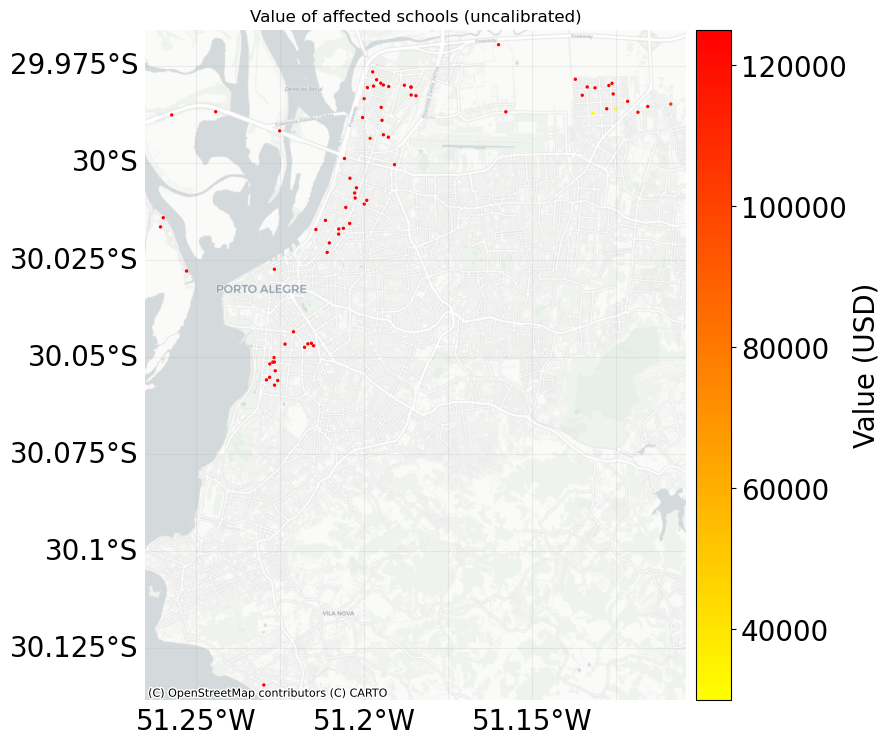

In [35]:
import contextily as ctx

def plot_event_impact(imp, title):
    axis = imp.plot_basemap_eai_exposure(
        ignore_zero=True,                   # Don't plot locations with zero impacts
        pop_name=False,                     # Don't plot place names
        buffer=500,                         # Add spatial buffers to the map (in the CRS coordinate units)
        s=2,                                # The size of point markers on the plot
        zoom=13,                            # Level of detail to add to the basemap
        url=ctx.providers.CartoDB.Positron, # Basemap provider
        cmap="autumn_r",                    # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
    )
    axis.set_title(title)
    return axis

# We can map the event impacts by individual exposure point:
_ = plot_event_impact(imp_residences_economic, title="Economic impact on residences (uncalibrated)")
_ = plot_event_impact(imp_residences_affected, title="Value of affected residences (uncalibrated)")

_ = plot_event_impact(imp_companies_economic, title="Economic impact on companies (uncalibrated)")
_ = plot_event_impact(imp_companies_affected, title="Value of affected companies (uncalibrated)")

_ = plot_event_impact(imp_schools_economic, title="Economic impact on schools (uncalibrated)")
_ = plot_event_impact(imp_schools_affected, title="Value of affected schools (uncalibrated)")

# Note: there are also methods to plot hexbin and raster plots (as with Exposures)

## Assets affected

What if we want to count the number of assets affected or the number damaged according to a particular thresholds? CLIMADA offers a couple of ways to do this.

In [72]:
# To get a broad sense of the value of exposures that are affected by any hazard (across all events), the Exposures' 
# `affected_total_value` attribute is helpful:
affected_value = entity.exposures.affected_total_value(
    hazard=haz,
    threshold_affected=0,
    overwrite_assigned_centroids=False
)
affected_households = affected_value / RESIDENCE_VALUE_USD
print(f"Total value of affected exposures: {affected_value:,.0f} USD")
print(f"Total number of affected households: {affected_households:,.0f}")

2026-05-23 02:19:01,348 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
Total value of affected exposures: 954,595,291 USD
Total number of affected households: 9,801


2026-05-23 02:19:23,602 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.
Average annual number of affected households: 67
Average annual value of affected housing: 6,499,644 USD


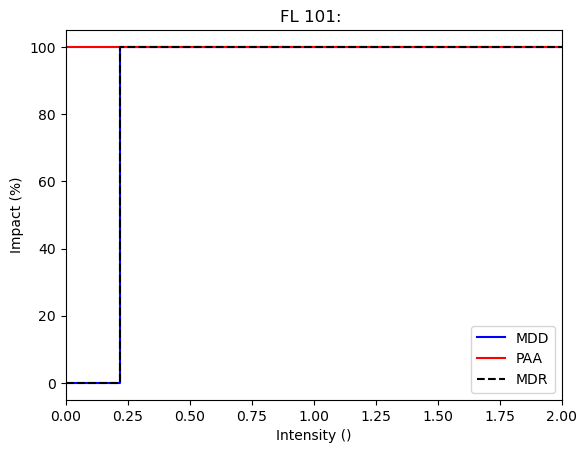

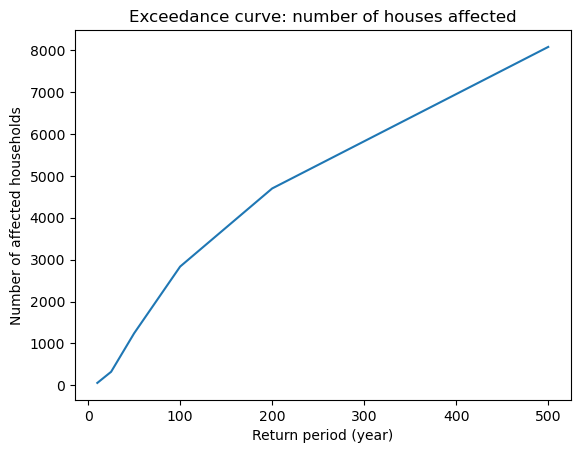

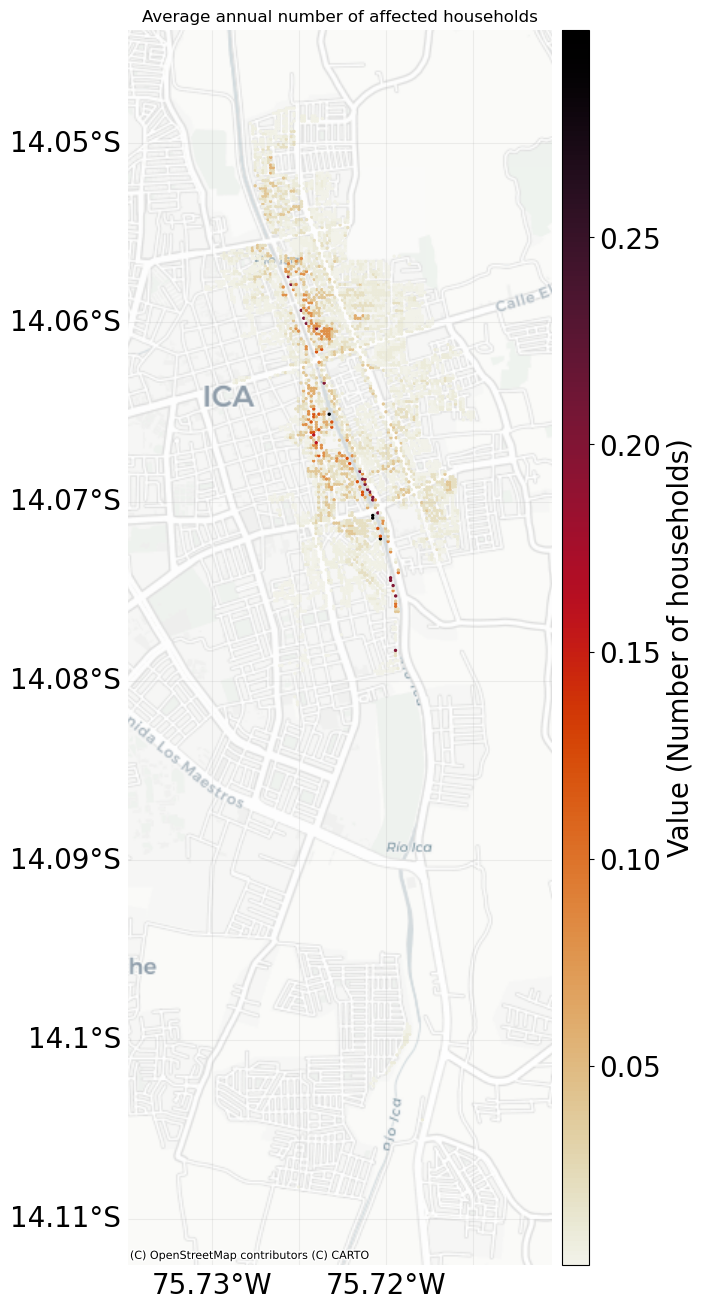

In [74]:
from climada.entity import ImpactFunc, ImpactFuncSet
# But to make this probabilistic – that is, to get the number of affected houses at different return periods, 
# or to get an average annual value – we need to run another impact calculation, this time with a step function as the 
# impact function.

# We can use inbuilt functionality to create a stepped impact function
# (Note that this is a bit redundant when we already have an step function in our impact function set,)
# (but you won't always have this, and creating custom step functions is very useful)
# First choose a flood depth that counts as affected:
affected_threshold = 0.22    # This is about the water depth where we model 20% impact with this uncalibrated impact function

# Create an impact function
affected_step_impf = ImpactFunc.from_step_impf(
    intensity=(0, affected_threshold, 2),
    haz_type="FL",
    mdd=(0, 1),
    paa=(1, 1),
    impf_id=101
)

# Plot the impact function
affected_step_impf.plot()

# Add it to a new ImpactFuncSet for use in a risk calculation
affected_impfset = ImpactFuncSet([affected_step_impf])

# We could do this next calculation with the affected value of houses, but let's divide our exposure by the value of an average house to get the number of affected households instead.
entity_households = copy.deepcopy(entity)
new_gdf = entity_households.exposures.gdf
new_gdf["value"] = new_gdf["value"] / RESIDENCE_VALUE_USD
entity_households.exposures.set_gdf(new_gdf)
entity_households.exposures.value_unit = "Number of households"

# And create a new ImpactCalc and Impact object
imp_calc_affected = ImpactCalc(
    exposures=entity_households.exposures,
    impfset=affected_impfset,
    hazard=haz
)
imp_affected = imp_calc_affected.impact(
    save_mat=True,          # Save the impact matrix (see below). This can be large, but we want it to explore some additional calculations 
    assign_centroids=False  # Don't (re)assign centroids 
)

# Now we can get probabilistic information on the average annual affected households and the household affected by return period
aal_affected_households = imp_affected.aai_agg
aal_affected_value = aal_affected_households * RESIDENCE_VALUE_USD
print(f"Average annual number of affected households: {aal_affected_households:,.0f}")
print(f"Average annual value of affected housing: {aal_affected_value:,.0f} USD")

# And we can extract an affected exceedance curve in the same way
affected_freq_curve = imp_affected.calc_freq_curve(return_per=HAZARD_RETURN_PERIODS)
axis = affected_freq_curve.plot()
_ = axis.set_title("Exceedance curve: number of houses affected")
_ = axis.set_ylabel("Number of affected households")

# And plot the expected value of affected households at custom return periods
axis_plot = imp_affected.plot_basemap_eai_exposure(
    ignore_zero=True,                   # Don't plot locations with zero impacts
    pop_name=False,                     # Don't plot place names
    buffer=500,                         # Add spatial buffers to the map (in the CRS coordinate units)
    s=2,                                # The size of point markers on the plot
    zoom=14,                            # Level of detail to add to the basemap
    url=ctx.providers.CartoDB.Positron  # Basemap provider
)
_ = axis_plot.set_title("Average annual number of affected households")
